--- STEP 1: DATASET ---
   Final_Grade  Project_Hrs  Study_Hrs
0           45            1          2
1           52            2          4
2           58            3          5
3           65            5          7
4           70            4          8
5           78            6         10
6           82            8         12
7           88            7         14
8           92            9         15
9           98           10         18

--- STEP 2: CORRELATION COEFFICIENTS ---
Final_Grade    1.0000
Project_Hrs    0.9752
Study_Hrs      0.9925
Name: Final_Grade, dtype: float64

--- STEP 3: REGRESSION PARAMETERS ---
Slope (m): 3.38241308793
Intercept (c): 40.6670756646
R-Squared: 0.9851

--- STEP 4: PREDICTION ---
Predicted Grade for 11 Study Hours: 77.87


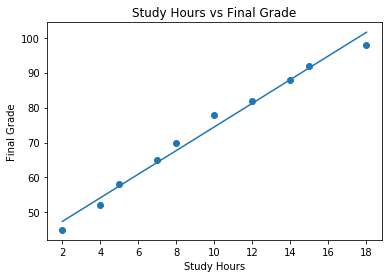

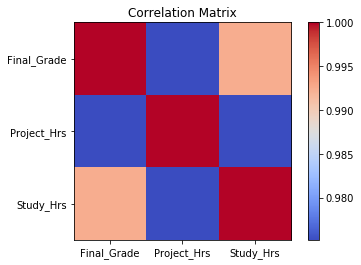

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# --- STEP 1: DATA PREPARATION ---
data = {
 'Study_Hrs': [2, 4, 5, 7, 8, 10, 12, 14, 15, 18],
 'Project_Hrs': [1, 2, 3, 5, 4, 6, 8, 7, 9, 10],
 'Final_Grade': [45, 52, 58, 65, 70, 78, 82, 88, 92, 98]
}

df = pd.DataFrame(data)

print("--- STEP 1: DATASET ---")
print(df)

# --- STEP 2: CORRELATION ---
corr_matrix = df.corr()

print("\n--- STEP 2: CORRELATION COEFFICIENTS ---")
print(corr_matrix['Final_Grade'].round(4))

# --- STEP 3: REGRESSION MODEL ---
X = df[['Study_Hrs']]
Y = df['Final_Grade']

model = LinearRegression()
model.fit(X, Y)

m = model.coef_[0]
c = model.intercept_
r_sq = model.score(X, Y)

print("\n--- STEP 3: REGRESSION PARAMETERS ---")
print("Slope (m):", m)
print("Intercept (c):", c)
print("R-Squared:", round(r_sq, 4))

# --- STEP 4: PREDICTION (FIXED) ---
new_input = np.array([[11]])   # ✅ FIXED INPUT
prediction = model.predict(new_input)

print("\n--- STEP 4: PREDICTION ---")
print("Predicted Grade for 11 Study Hours:", round(prediction[0], 2))

# --- STEP 5: VISUALIZATION (MATPLOTLIB ONLY) ---

# 1. Scatter Plot
plt.figure()
plt.scatter(df['Study_Hrs'], df['Final_Grade'])

# Regression Line
y_pred_line = model.predict(X)
plt.plot(df['Study_Hrs'], y_pred_line)

plt.title("Study Hours vs Final Grade")
plt.xlabel("Study Hours")
plt.ylabel("Final Grade")
plt.show()

# 2. Correlation Heatmap (manual)
plt.figure()
plt.imshow(corr_matrix, cmap='coolwarm')

plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title("Correlation Matrix")
plt.show()